In [ ]:
from google.colab import files
uploaded = files.upload()


Saving mine_quarry_25k_ngdr_20250224140917945.dbf to mine_quarry_25k_ngdr_20250224140917945.dbf
Saving mine_quarry_25k_ngdr_20250224140917945.prj to mine_quarry_25k_ngdr_20250224140917945.prj
Saving mine_quarry_25k_ngdr_20250224140917945.shp to mine_quarry_25k_ngdr_20250224140917945.shp
Saving mine_quarry_25k_ngdr_20250224140917945.shx to mine_quarry_25k_ngdr_20250224140917945.shx


In [ ]:
import geopandas as gpd


gdf = gpd.read_file("mine_quarry_25k_ngdr_20250224140917945.shp")  # Don't include the other extensions


In [ ]:
gdf.columns

Index(['gid', 'input_cent', 'edition_no', 'toposheet_', 'commodity', 'status',
       'accession_', 'remarks', 'geometry'],
      dtype='object')

In [ ]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   gid         40 non-null     int32   
 1   input_cent  40 non-null     object  
 2   edition_no  40 non-null     int32   
 3   toposheet_  40 non-null     object  
 4   commodity   40 non-null     object  
 5   status      40 non-null     object  
 6   accession_  0 non-null      object  
 7   remarks     0 non-null      object  
 8   geometry    40 non-null     geometry
dtypes: geometry(1), int32(2), object(6)
memory usage: 2.6+ KB


In [ ]:
gdf.shape


(40, 9)

In [ ]:
gdf.describe()

,gid,edition_no
count,40.000000,40.0
mean,96.500000,1.0
std,11.690452,0.0
min,77.000000,1.0
25%,86.750000,1.0
50%,96.500000,1.0
75%,106.250000,1.0
max,116.000000,1.0


✅ Initial Columns: ['gid', 'input_cent', 'edition_no', 'toposheet_', 'commodity', 'status', 'accession_', 'remarks', 'geometry']
💾 Saved cleaned dataset to: final_cleaned_mine_quarry_data.csv
📊 Final Data Shape: (40, 2)
📌 Columns: ['gid', 'toposheet_']


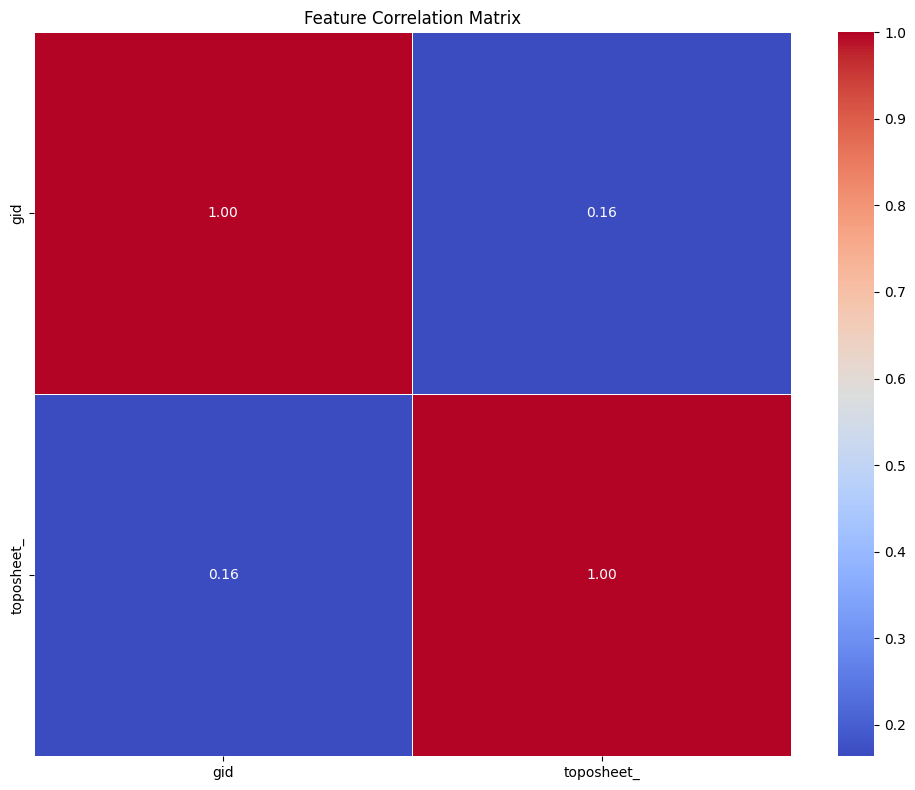


🔍 Correlation with Target Variable:
toposheet_    1.000000
gid           0.163763
Name: toposheet_, dtype: float64

📊 Random Forest Evaluation:
   RMSE       : 0.2890
   R² Score   : 0.5545
   Accuracy   : 55.45%

📊 XGBoost Evaluation:
   RMSE       : 0.0009
   R² Score   : 1.0000
   Accuracy   : 100.00%

📊 Gradient Boosting Evaluation:
   RMSE       : 0.3536
   R² Score   : 0.3333
   Accuracy   : 33.33%

🏆 Best Model: XGBoost with Accuracy: 100.00%


In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ---------------------------- Load Shapefile ----------------------------

shapefile_path = "mine_quarry_25k_ngdr_20250224140917945.shp"
gdf = gpd.read_file(shapefile_path)
print("✅ Initial Columns:", gdf.columns.tolist())

# ---------------------------- Data Cleaning ----------------------------

if "geometry" in gdf.columns:
    gdf.drop(columns=["geometry"], inplace=True)

# Drop null, mostly null, or constant columns
columns_to_drop = []
for col in gdf.columns:
    if gdf[col].isnull().all() or gdf[col].nunique() <= 1 or gdf[col].isnull().mean() > 0.9:
        columns_to_drop.append(col)

irrelevant_cols = ["accession_", "remarks", "objectid", "fid", "uuid", "id"]
columns_to_drop += [col for col in irrelevant_cols if col in gdf.columns]
gdf.drop(columns=list(set(columns_to_drop)), inplace=True)

# Fill missing values
for col in gdf.columns:
    if gdf[col].dtype == "object":
        gdf[col] = gdf[col].fillna("Unknown")
    else:
        gdf[col] = gdf[col].fillna(gdf[col].mean())

# Label encode categorical columns
for col in gdf.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    gdf[col] = le.fit_transform(gdf[col].astype(str))

# ---------------------------- Save Cleaned Data ----------------------------

cleaned_csv_path = "final_cleaned_mine_quarry_data.csv"
gdf.to_csv(cleaned_csv_path, index=False)
print(f"💾 Saved cleaned dataset to: {cleaned_csv_path}")
print("📊 Final Data Shape:", gdf.shape)
print("📌 Columns:", gdf.columns.tolist())

# ---------------------------- Correlation Matrix ----------------------------

plt.figure(figsize=(10, 8))
sns.heatmap(gdf.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# ---------------------------- Prepare Features and Target ----------------------------

# Choose target column
target_column = "edition_no" if "edition_no" in gdf.columns else gdf.columns[-1]

# Show correlation with target
correlations = gdf.corr()[target_column].sort_values(ascending=False)
print("\n🔍 Correlation with Target Variable:")
print(correlations)

X = gdf.drop(columns=[target_column])
y = gdf[target_column]

# ---------------------------- Standardize Data ----------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

# ---------------------------- Train-Test Split ----------------------------

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------- Model Training ----------------------------

rf = RandomForestRegressor(n_estimators=100, random_state=42)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, objective="reg:squarederror", random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)

rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
gb.fit(X_train, y_train)

# ---------------------------- Predictions ----------------------------

y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)
y_pred_gb = gb.predict(X_test)

# ---------------------------- Evaluation ----------------------------

def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    accuracy = r2 * 100
    print(f"\n📊 {model_name} Evaluation:")
    print(f"   RMSE       : {rmse:.4f}")
    print(f"   R² Score   : {r2:.4f}")
    print(f"   Accuracy   : {accuracy:.2f}%")
    return accuracy

acc_rf = evaluate(y_test, y_pred_rf, "Random Forest")
acc_xgb = evaluate(y_test, y_pred_xgb, "XGBoost")
acc_gb = evaluate(y_test, y_pred_gb, "Gradient Boosting")

# ---------------------------- Best Model Summary ----------------------------

best_model = max([(acc_rf, "Random Forest"), (acc_xgb, "XGBoost"), (acc_gb, "Gradient Boosting")])
print(f"\n🏆 Best Model: {best_model[1]} with Accuracy: {best_model[0]:.2f}%")


✅ Initial Columns: ['gid', 'input_cent', 'edition_no', 'toposheet_', 'commodity', 'status', 'accession_', 'remarks', 'geometry']
⚠️ No depth-related column found. Skipping depth modeling.
💾 Saved cleaned dataset to: final_cleaned_mine_quarry_data.csv
📊 Final Data Shape: (40, 2)
📌 Columns: ['gid', 'toposheet_']


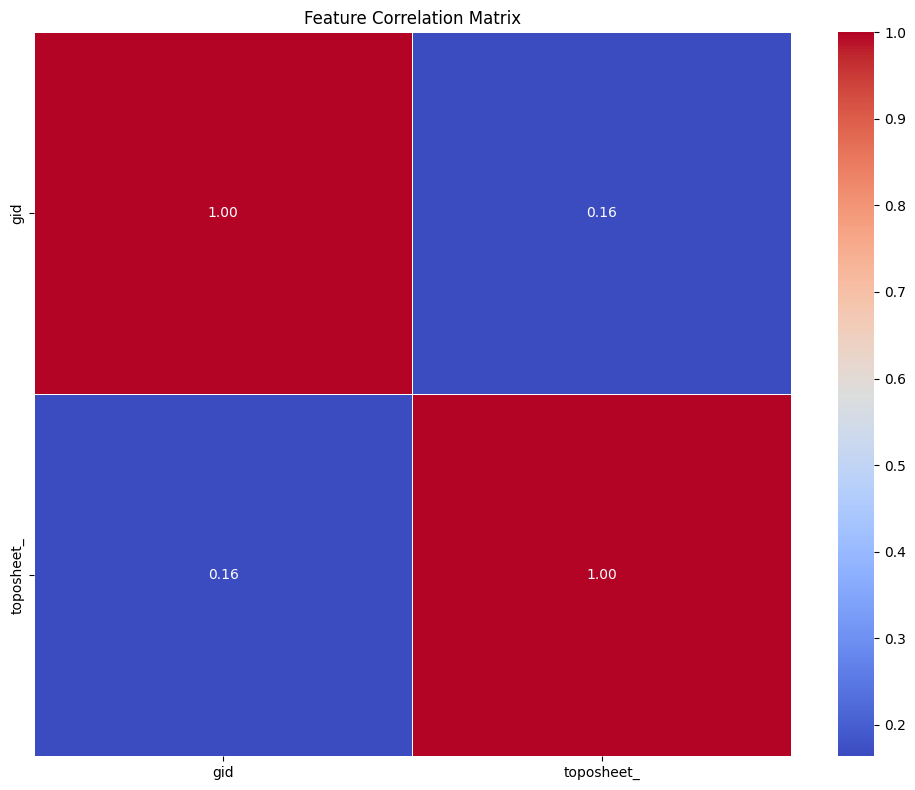


🔍 Correlation with Target Variable:
toposheet_    1.000000
gid           0.163763
Name: toposheet_, dtype: float64

📊 Random Forest Evaluation:
   RMSE       : 0.2890
   R² Score   : 0.5545
   Accuracy   : 55.45%

📊 XGBoost Evaluation:
   RMSE       : 0.0009
   R² Score   : 1.0000
   Accuracy   : 100.00%

📊 Gradient Boosting Evaluation:
   RMSE       : 0.3536
   R² Score   : 0.3333
   Accuracy   : 33.33%

🏆 Best Model: XGBoost with Accuracy: 100.00%
